## Project Objective

The goal of this analysis is to explore customer shopping behavior patterns,
understand customer demographics, purchasing trends, and identify useful
business insights from the dataset.

### Exploratory Data Analysis (EDA)
### Customer Shopping Behaviour Dataset

In [2]:
# Import required libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve chart appearance
sns.set_style('whitegrid')

In [5]:
# Load the dataset

df = pd.read_csv('../data/raw/customer_shopping_behavior.csv')

In [6]:
# Display first 5 rows of the dataset

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [8]:
# Check total number of rows and columns in the dataset

df.shape

(5050, 17)

In [11]:
# Check total number of records in the dataset

len(df)

5050

In [10]:
# Display dataset information such as data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [ ]:
# Generate descriptive statistics for numerical columns

df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [13]:
# Check missing values in each column

df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [14]:
# Display all column names in the dataset

df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [52]:
# Check for duplicate customer IDs

df['Customer ID'].duplicated().sum()

np.int64(50)

In [22]:
# Display number of unique values and values list

for col in df.select_dtypes(include='object').columns:
    print(f'\nColumns: {col}')
    print(f'Unique values: {df[col].nunique()}')
    print(df[col].unique())


Columns: Gender
Unique values: 3
['Female' 'Male' 'Other']

Columns: Item Purchased
Unique values: 30
['T-shirt' 'Sunglasses' 'Shirt' 'Gloves' 'Jewelry' 'Shorts' 'Hat'
 'Handbag' 'Shoes' 'Coat' 'Laptop' 'Hoodie' 'Phone' 'Jacket' 'Pants'
 'Backpack' 'Socks' 'Jeans' 'Bag' 'Belt' 'Watch' 'Headphones' 'Blouse'
 'Sandals' 'Skirt' 'Sweater' 'Scarf' 'Sneakers' 'Boots' 'Dress']

Columns: Category
Unique values: 5
['Clothing' 'Accessories' 'Outerwear' 'Electronics' 'Footwear']

Columns: Location
Unique values: 54
['California' 'South Carolina' 'Montana' 'Illinois' 'Alabama' 'Wisconsin'
 'Tennessee' 'Florida' 'Kentucky' 'Phoenix' 'Pennsylvania' 'Los Angeles'
 'Vermont' 'North Dakota' 'Ohio' 'Colorado' 'Maine' 'Massachusetts'
 'Arkansas' 'New York' 'Indiana' 'Maryland' 'New Mexico' 'Michigan'
 'Connecticut' 'Louisiana' 'Minnesota' 'Oregon' 'Kansas' 'Houston'
 'South Dakota' 'New Jersey' 'New Hampshire' 'North Carolina' 'Hawaii'
 'Nebraska' 'Virginia' 'Chicago' 'Iowa' 'Oklahoma' 'Delaware' 'Utah'

In [30]:
# Display all rows and columns without truncation

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [29]:
# View items grouped by category

df.groupby('Category')['Item Purchased'].unique()

Category
Accessories               [Sunglasses, Gloves, Jewelry, Hat, Handbag, Phone, Backpack, Belt, Bag, Headphones, Scarf, Watch, Shirt, Shoes, Laptop]
Clothing       [T-shirt, Shirt, Shorts, Shoes, Hoodie, Phone, Pants, Socks, Jeans, Bag, Blouse, Skirt, Sweater, Watch, Laptop, Dress, Headphones]
Electronics                                                                                 [Laptop, Phone, Watch, Bag, Shoes, Shirt, Headphones]
Footwear                                                                                                        [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                                                                          [Coat, Jacket]
Name: Item Purchased, dtype: object

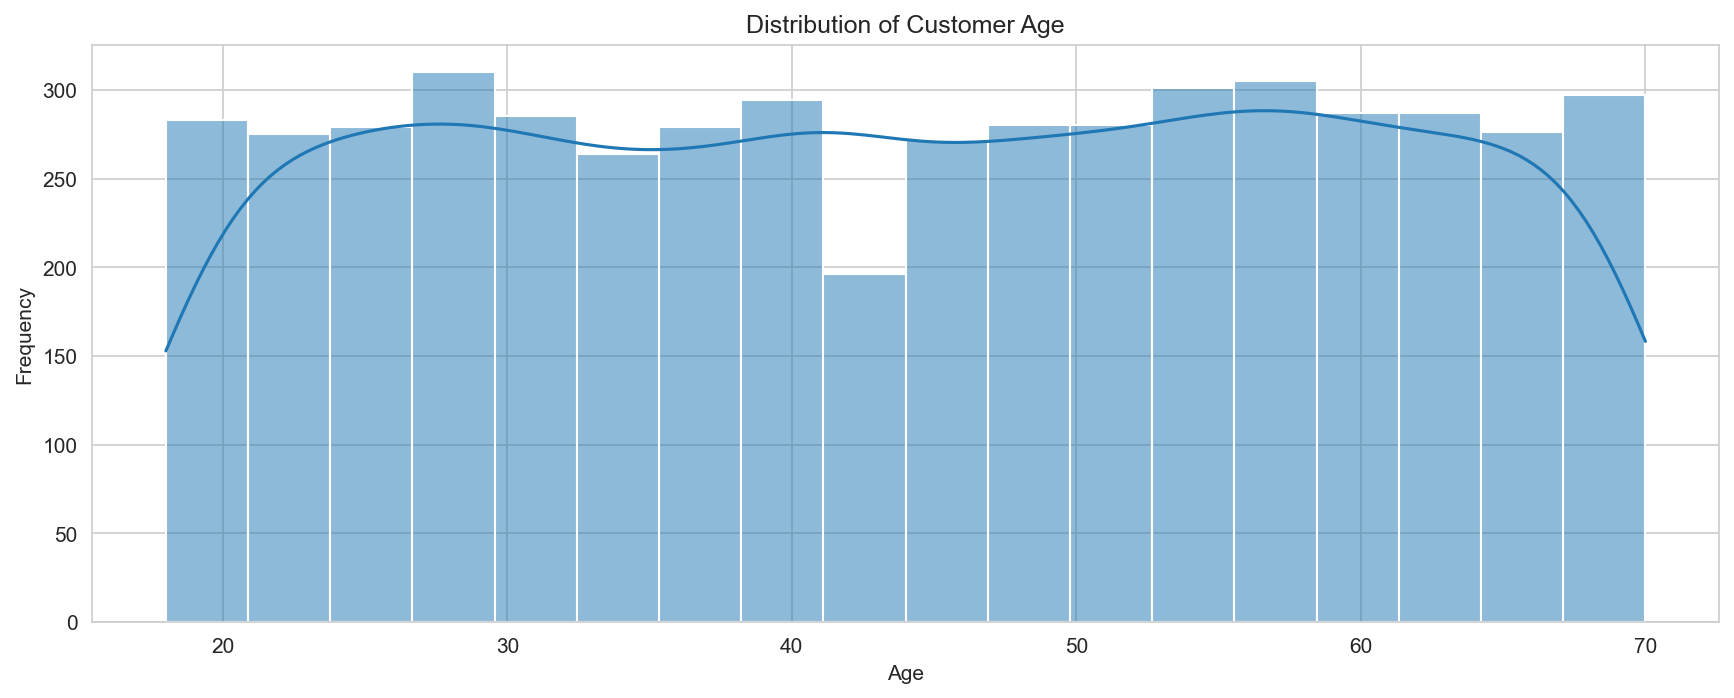

In [36]:
## Age Distribution Analysis

plt.figure(figsize=(14,5), dpi=150)

sns.histplot(data=df, x='Age', kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()



### Insight: Customer ages are fairly evenly distributed, with slightly higher concentration in the middle-age groups (around 25–60 years).

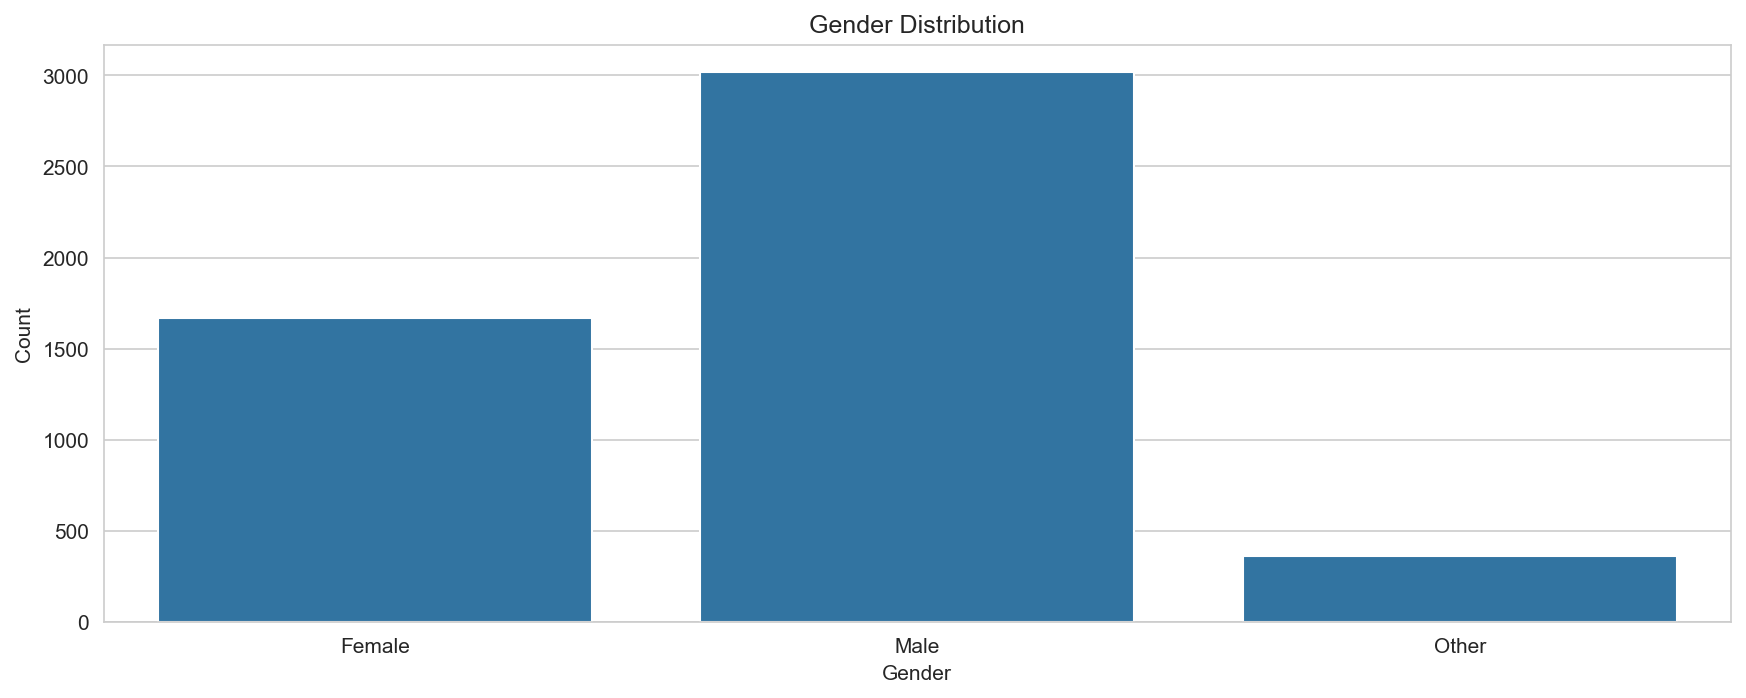

In [38]:
## Customer count by gender

plt.figure(figsize=(14,5), dpi=150)

sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Insight: Male customers represent the largest customer segment, followed by female customers, while the 'Other' category has the lowest representation.

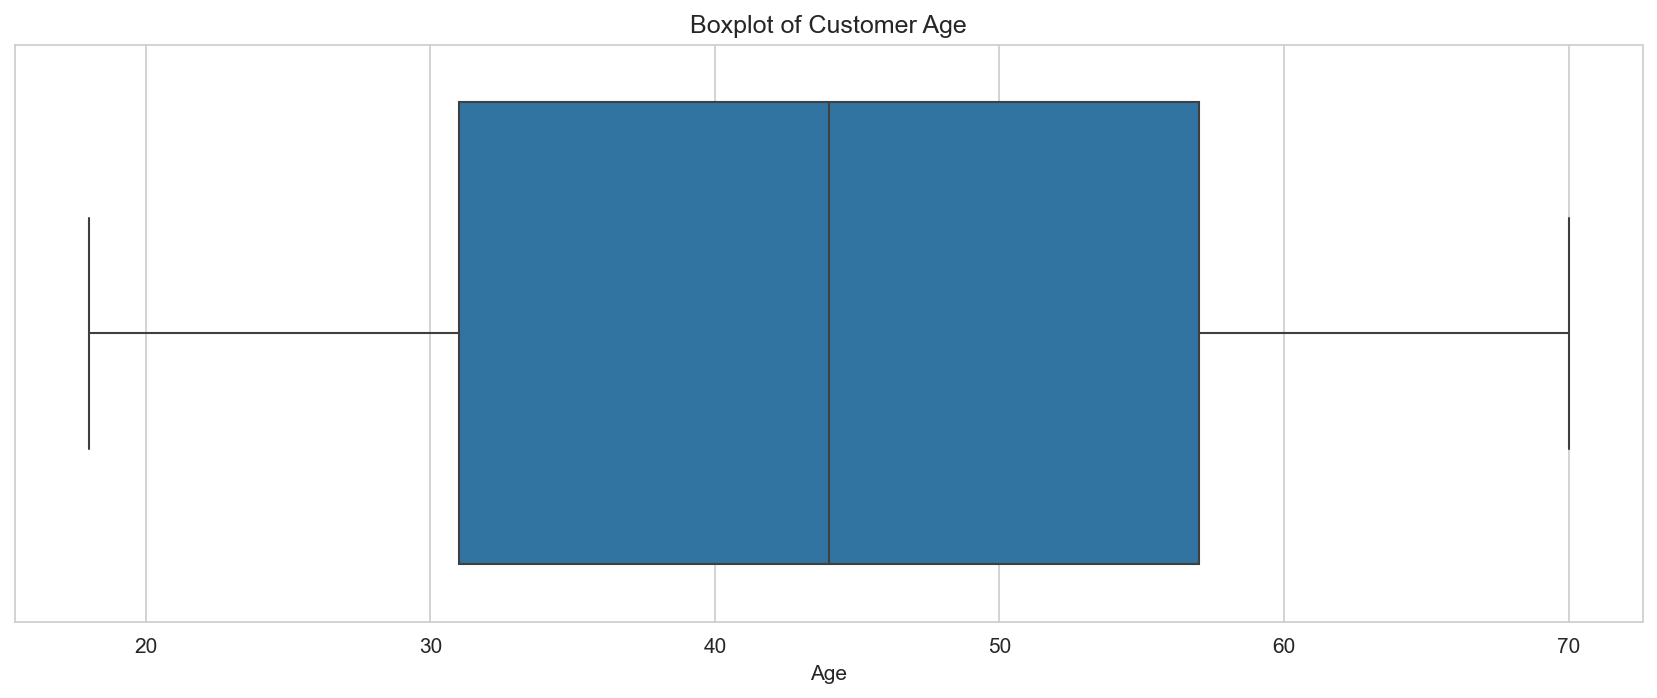

In [40]:
# Check outliers in customer age using boxplot

plt.figure(figsize=(14,5), dpi=150)

sns.boxplot(data=df, x='Age')
plt.title("Boxplot of Customer Age")
plt.xlabel("Age")
plt.show()

In [41]:
df.head(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly


### Insight: Customer age distribution appears balanced with no significant outliers, indicating ages are within a reasonable range.

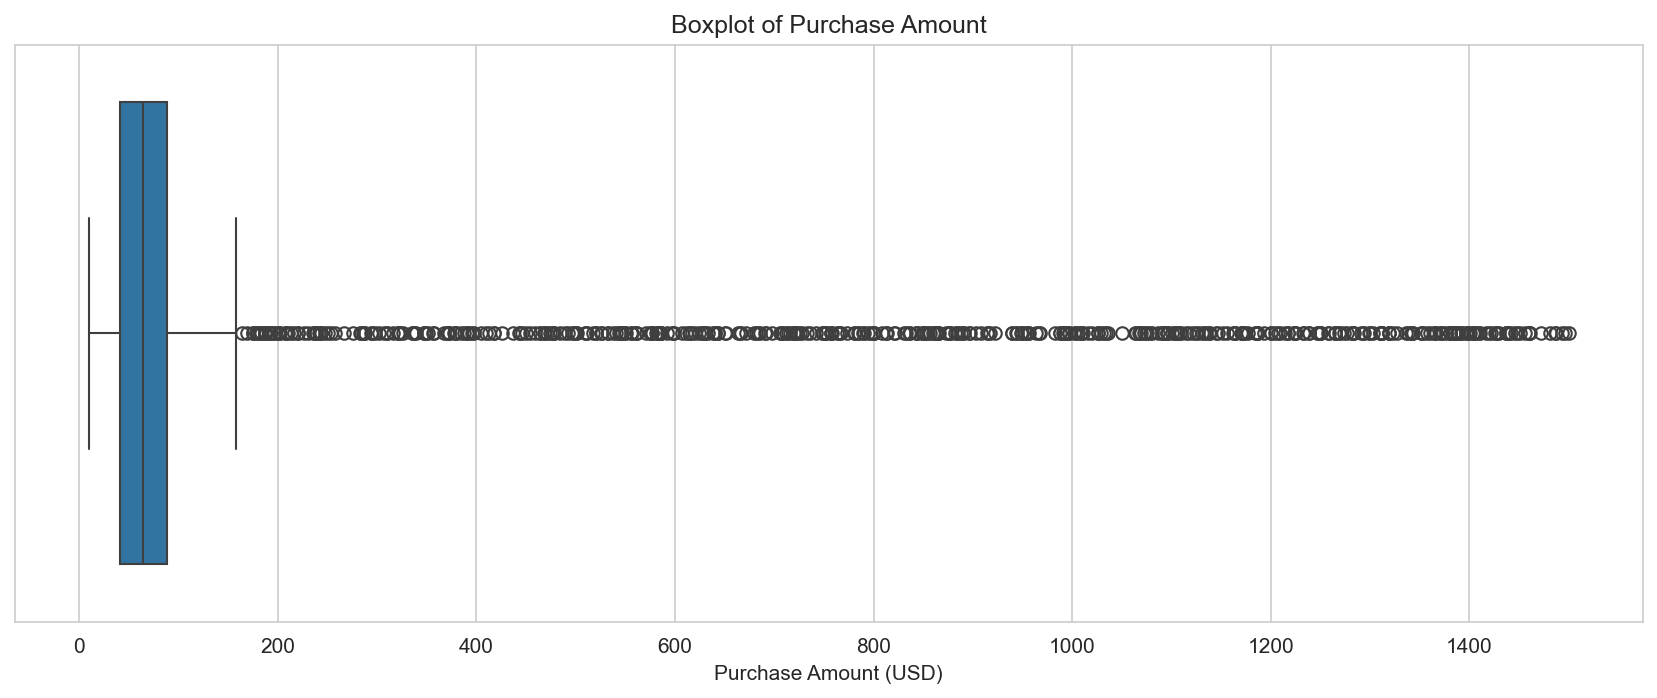

In [42]:
plt.figure(figsize=(14,5), dpi=150)

sns.boxplot(data=df, x='Purchase Amount (USD)')
plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount (USD)")
plt.show()

### Insight: Purchase amounts are right-skewed with several high-value outliers, indicating a small number of transactions are significantly larger than most purchases.

In [ ]:
# This gives you the count for every location, sorted from highest to lowest
top_cities = df['Location'].value_counts()[:10]

top_cities

Location
New York       337
Los Angeles    236
Houston        210
Phoenix        208
Chicago        196
Montana         97
California      96
Idaho           96
Illinois        94
Alabama         90
Name: count, dtype: int64

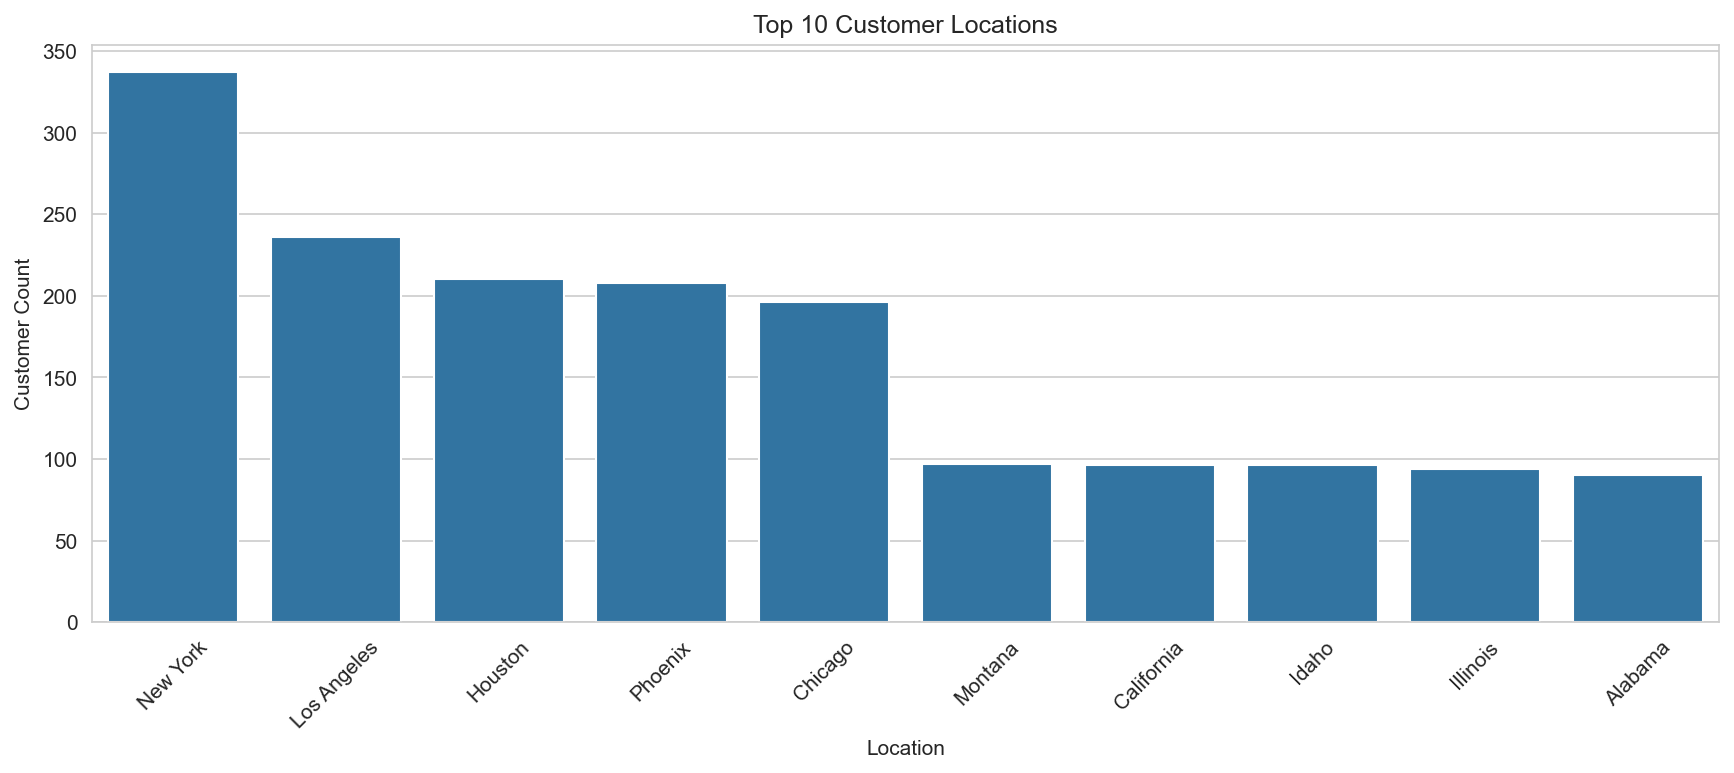

In [51]:
# Visualize top 10 customer locations

plt.figure(figsize=(14,5), dpi=150)

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.title("Top 10 Customer Locations")
plt.xlabel("Location")
plt.ylabel("Customer Count")

plt.xticks(rotation=45)

plt.show()

## End of Exploratory Data Analysis


## Data Quality Issues Identified

During exploratory analysis, several data quality issues were identified:

- Missing values detected in:
  - Purchase Amount (USD)
  - Size
  - Review Rating
  - Previous Purchases

- Duplicate Customer IDs were observed

- Some products appeared under unexpected categories,
  indicating possible category inconsistencies

- Column names are not in a standardized format and
  will be converted into snake_case format during preprocessing

These issues will be addressed in the next stage
of the project during data cleaning and preprocessing.